In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

In [4]:
df

,datetime,speed,power_cf,power
0,2018-01-01 01:00:00,6.384246,0.191033,134.039
1,2018-01-01 02:00:00,6.679563,0.220842,123.450
2,2018-01-01 03:00:00,6.784414,0.232067,116.143
3,2018-01-01 04:00:00,6.794198,0.233133,94.625
4,2018-01-01 05:00:00,7.114358,0.269688,41.765
...,...,...,...,...
34851,2021-12-31 13:00:00,2.544705,0.000000,5.338
34852,2021-12-31 14:00:00,2.059370,0.000000,6.463
34853,2021-12-31 15:00:00,3.659931,0.024277,10.312
34854,2021-12-31 16:00:00,4.747566,0.070125,16.813


In [ ]:
# df1 = df[:8760]
# df2 = df[8760:17520]
# df3 = df[17520:26304]
# df4 = df[26304:]

In [5]:
# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

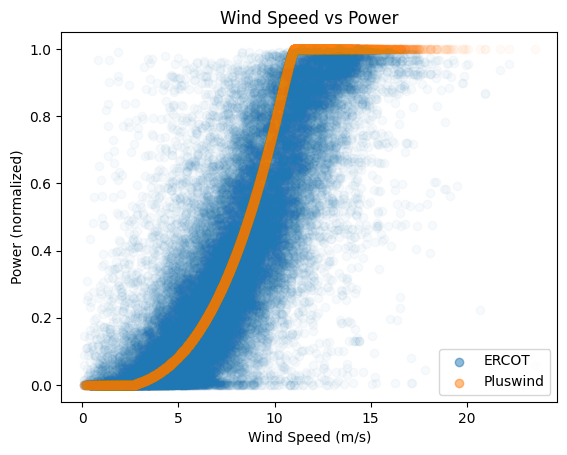

In [6]:
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (normalized)')
plt.title('Wind Speed vs Power')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)

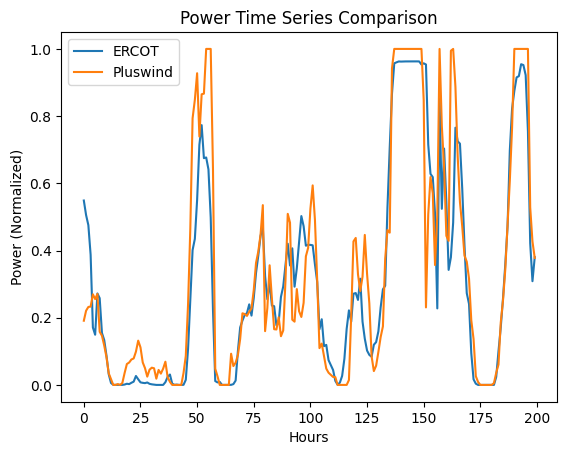

In [7]:
plt.plot(df['npower'][:200], label='ERCOT')
plt.plot(df['power_cf'][:200], label='Pluswind')
plt.title('Power Time Series Comparison')
plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.legend()

In [8]:
# split into years
df1 = df[:8596].reset_index(drop=True)         # n=8596 
df2 = df[8596:17327].reset_index(drop=True)    # n=8731
df3 = df[17327:26108].reset_index(drop=True)   # n=8781 (leap year)
df4 = df[26108:].reset_index(drop=True)        # n=8753

## seasonal fluctuations?

In [9]:
time = df1['datetime']
t = np.arange(8596)
A = 0.5
B = 0.3

seasonal = A * np.sin(2 * np.pi * t / 8596)
daily = B * np.sin(2 * np.pi * t / 24)
noise = np.random.normal(0, 0.05, size=8596)
weight = seasonal + daily + noise

sorted_power = np.sort(df1['npower'])
weight_order = np.argsort(weight)
sorted = np.empty_like(sorted_power)
sorted[weight_order] = sorted_power

df1['sorted'] = sorted

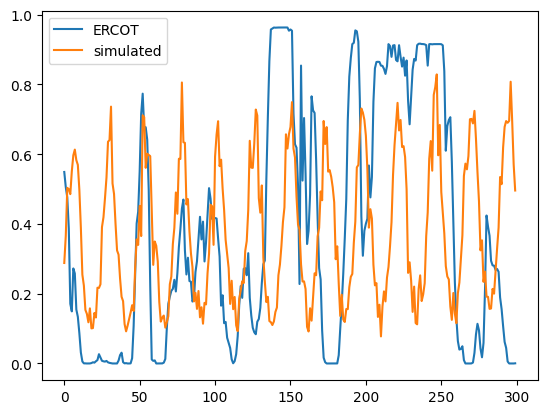

In [10]:
plt.plot(df1['npower'][:300], label='ERCOT')
plt.plot(df1['sorted'][:300], label='simulated')
plt.legend()

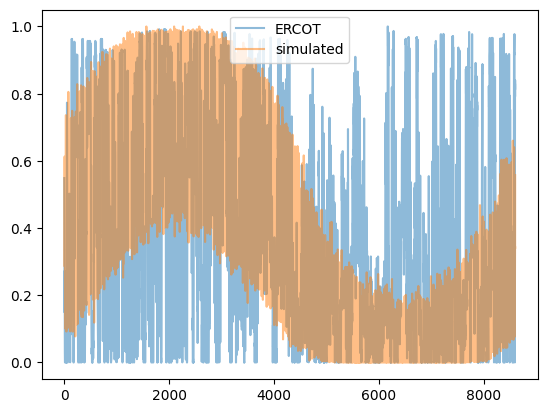

In [11]:
plt.plot(df1['npower'][:8596], label='ERCOT', alpha=0.5)
plt.plot(df1['sorted'][:8596], label='simulated', alpha=0.5)
plt.legend()

# Using deterministic power curve

$Power = 1/2 * \rho * A * v^3$

$\rho$ : density of air (kg/m^3) - standard is 1.225 kg/m^3

$A$ : cross sectional area of wind, swept area (m^2)

$v$ : velocity of wind (m/s)

pyron has 166 turbines, each operating at 1.5 MW (max)

pyron wind turbine: cut-in at 3.5 m/s, rated wind speed at 12 m/s, cut-out at 25 m/s

In [12]:
radius = 77 / 2
area = np.pi * radius**2
area

4656.625710783471

In [13]:
# all pyron turbine power in MW
power = 0.5 * 1.225 * area * df1['speed']**3 * 166 / 1e6

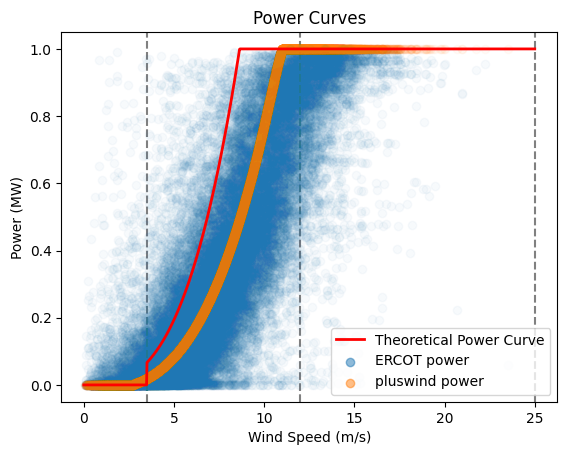

In [14]:
x = np.linspace(0, 25, 1000)

# one turbine
# y = 0.5 * area * x**3 / 1e6
# y = [1.5 if val > 1.5 else val for val in y]

# all pyron turbines
y = 0.5 * area * x**3 * 166 / 1e6
y = [0 if speed < 3.5 else val for speed, val in zip(x, y)]
y = [249 if val > 249 else val for val in y]
y = [val / 249 for val in y] # normalize
plt.plot(x, y, label='Theoretical Power Curve', color='red', linewidth=2)

plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT power')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='pluswind power')

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.title('Power Curves')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)
leg.legend_handles[0].set_alpha(1)

### 5 Parameter Logistic

$ y = f(x;p) = f(x;a,b,c,d,g) = d + \frac{a-d}{(1+(\frac{x}{c})^b)^g} $

In [15]:
from scipy.optimize import curve_fit

In [16]:
def raw_5pl(x, a, b, c, d, g):
    return d + (a - d) / (1 + (x / c) ** b) ** g

# scale y to 0-249
def constrained_5pl(x, a, b, c, d, g, max_power=249):
    y_raw = raw_5pl(x, a, b, c, d, g)
    y_min = raw_5pl(3.5, a, b, c, d, g)
    y_max = raw_5pl(12, a, b, c, d, g)
    return max_power * (y_raw - y_min) / (y_max - y_min)

def full_power_curve(x, a, b, c, d, g, max_power=249):
    x = np.array(x)
    y = np.zeros_like(x)
    clipped_speeds = (x >= 3.5) & (x <= 12)
    y[clipped_speeds] = constrained_5pl(x[clipped_speeds], a, b, c, d, g, max_power)
    y[(x > 12) & (x <= 25)] = max_power
    return y

In [17]:
clipped_speeds = (df['speed'] >= 3.5) & (df['speed'] <= 12)
x_clip = df['speed'][clipped_speeds].values
y_clip = df['power'][clipped_speeds].values

initial_guess = [0, 1, 1, 249, 1]

params, _ = curve_fit(constrained_5pl, x_clip, y_clip, p0=initial_guess, maxfev=10000)

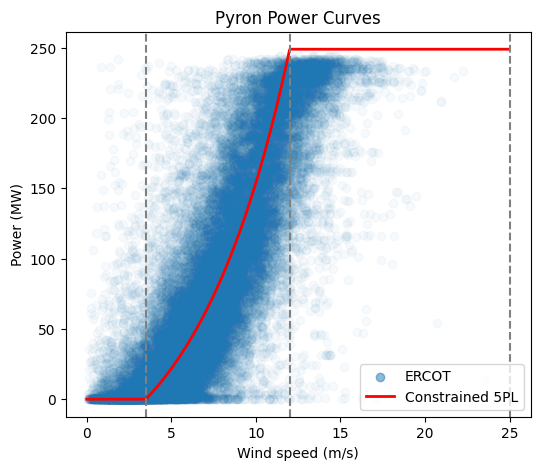

In [18]:
x = np.linspace(0, 25, 1000)
y = full_power_curve(x, *params, max_power=249)

plt.figure(figsize=(6, 5))
plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.plot(x, y, color='red', label='Constrained 5PL', linewidth=2)
plt.axvline(3.5, linestyle='--', color='gray')
plt.axvline(12, linestyle='--', color='gray')
plt.axvline(25, linestyle='--', color='gray')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Pyron Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

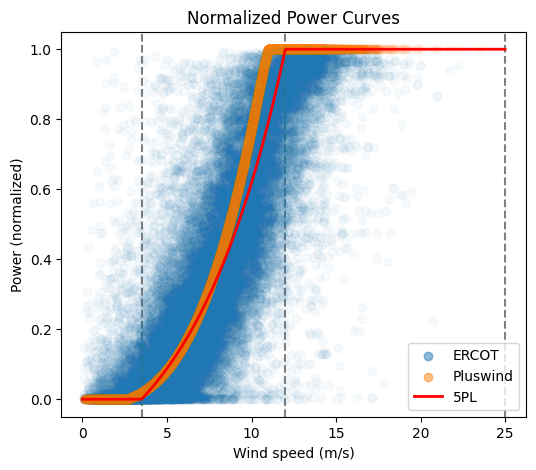

In [19]:
# normalized, plotted with pluswind

x = np.linspace(0, 25, 1000)
y = full_power_curve(x, *params)
y = [val / 249 for val in y]  # normalize

plt.figure(figsize=(6, 5))
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.plot(x, y, color='red', label='5PL', linewidth=2)

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (normalized)')
plt.title('Normalized Power Curves')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)
leg.legend_handles[2].set_alpha(1)

In [20]:
params

array([-2.15748257e+07,  1.15500826e+00,  3.90734372e+03, -4.71764465e+09,
       -1.36789219e+03])

In [21]:
for i in range(26):
    print(f"speed: {i}", f"power: {full_power_curve(i, *params)}")

speed: 0 power: 0
speed: 1 power: 0
speed: 2 power: 0
speed: 3 power: 0
speed: 4 power: 6
speed: 5 power: 21
speed: 6 power: 39
speed: 7 power: 61
speed: 8 power: 87
speed: 9 power: 117
speed: 10 power: 154
speed: 11 power: 197
speed: 12 power: 249
speed: 13 power: 249
speed: 14 power: 249
speed: 15 power: 249
speed: 16 power: 249
speed: 17 power: 249
speed: 18 power: 249
speed: 19 power: 249
speed: 20 power: 249
speed: 21 power: 249
speed: 22 power: 249
speed: 23 power: 249
speed: 24 power: 249
speed: 25 power: 249


## time series with deterministic curve

In [22]:
power = full_power_curve(df['speed'], *params)

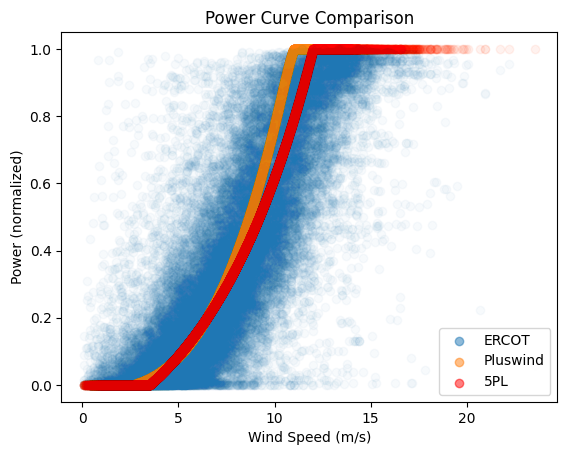

In [23]:
plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.scatter(df['speed'], power/249, alpha=0.03, color='red', label='5PL')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (normalized)')
plt.title('Power Curve Comparison')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)

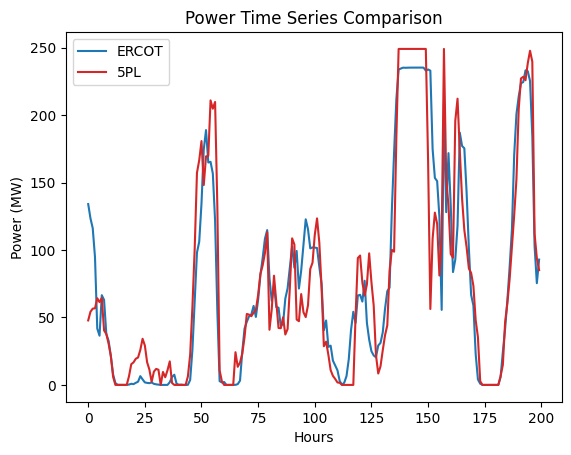

In [24]:
# time series
plt.plot(df['power'][:200], label='ERCOT', color='tab:blue')
plt.plot(power[:200], label='5PL', color='tab:red')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Power Time Series Comparison')
plt.legend()

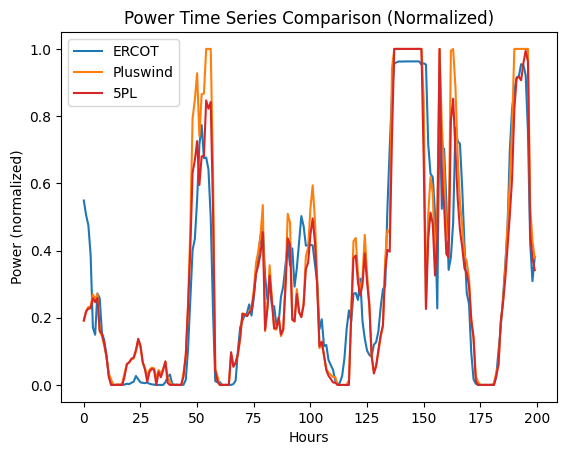

In [25]:
# normalized time series with pluswind
plt.plot(df['npower'][:200], label='ERCOT')
plt.plot(df['power_cf'][:200], label='Pluswind')
plt.plot(power[:200]/249, label='5PL', color='tab:red')
plt.xlabel('Hours')
plt.ylabel('Power (normalized)')
plt.title('Power Time Series Comparison (Normalized)')
plt.legend()

In [26]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [27]:
# comparing ERCOT and Pluswind
print("MSE:", mean_squared_error(df['npower'], df['power_cf']))
print("RMSE:", root_mean_squared_error(df['npower'], df['power_cf']))
print("R2:", r2_score(df['npower'], df['power_cf']))

MSE: 0.047011942247820654
RMSE: 0.2168223748781953
R2: 0.5043963287405123


In [28]:
# comparing ERCOT and 5PL
print("MSE:", mean_squared_error(df['npower'], power/249))
print("RMSE:", root_mean_squared_error(df['npower'], power/249))
print("R2:", r2_score(df['npower'], power/249))

MSE: 0.037122683541293965
RMSE: 0.1926724773840155
R2: 0.6086496883475956


In [29]:
turbines = pd.read_csv('../../data/processed/uswtdb_V8_1_20250522.csv')
turbines = turbines[turbines['p_name'] == 'Pyron (Roscoe III)'].reset_index(drop=True)
turbines = turbines[['case_id', 'xlong', 'ylat']]

# Jensen model wake loss

$ U_{in} = U_\infty \cdot [1 - \frac{1 - \sqrt{1 - C_T}}{(1 + k_w \cdot x/D)^2}] $ 

$U_{in}$ : wind speed at downstream turbine

$U_\infty$ : free-stream wind speed

$C_T$ : thrust coefficient (will assume 0.75)

$k_w$ : wake decay constant (0.075 onshore)

$x$ : downstream distance from wake-generating turbine

$D$ : rotor diameter

In [30]:
from pyproj import Proj, transform

In [31]:
def jensen_deficit(U_inf, C_T, k_w, x, D):
    return U_inf * (1 - (1 - np.sqrt(1 - C_T)) / (1 + k_w * x / D)**2)

def combine_deficits(deficits):
    return np.sqrt(sum(np.array(deficits)**2))

# convert latitude and longitude to UTM coordinates
def utm(longitude, latitude):
    proj_latlon = Proj(proj='latlong', datum='WGS84')
    proj_utm = Proj(proj='utm', zone=14, datum='WGS84') # pyron in UTM zone 14N
    easting, northing = transform(proj_latlon, proj_utm, longitude, latitude)
    return easting, northing

# computes downwind and crosswind distances between 2 turbines
def compute_distances(turb_i, turb_j, wind_direction=270):
    # default wind direction east to west (270 deg)
    theta = np.radians(wind_direction)

    dx = turb_i.easting - turb_j.easting
    dy = turb_i.northing - turb_j.northing

    # rotate coords to align with wind direction
    x = dx * np.cos(theta) + dy * np.sin(theta)
    y = -dx * np.sin(theta) + dy * np.cos(theta)

    # downwind distance, crosswind distance
    return x, y

In [32]:
turbines['easting'], turbines['northing'] = utm(turbines['xlong'], turbines['ylat'])

In [33]:
D = 77
C_T = 0.75
k_w = 0.075

In [34]:
# wake loss for each turbine at 1 wind speed
U_inf = 12

for i, turb_i in enumerate(turbines.itertuples()):
    deficits = []
    for j, turb_j in enumerate(turbines.itertuples()):
        if j == i:
            continue
        x, y = compute_distances(turb_i, turb_j)
        if x > 0 and abs(y) < (D/2 + k_w * x):
            deficit = jensen_deficit(U_inf, C_T, k_w, x, D)
            deficits.append(U_inf - deficit)
    delta_U = combine_deficits(deficits)
    U_in = - delta_U

In [35]:
U_inf + U_in

10.38589117284128

In [38]:
full_power_curve(U_inf + U_in, *params)

array(169.82998992)

In [39]:
# power curve with wake loss
def power_wakeloss(speeds, turbines, params, D=77, C_T=0.75, k_w=0.075):
    powers = []
    
    for speed in speeds:
        U_inf = speed
        turb_powers = []

        # compute wake loss
        for i, turb_i in enumerate(turbines.itertuples()):
            deficits = []
            for j, turb_j in enumerate(turbines.itertuples()):
                if j == i:
                    continue
                x, y = compute_distances(turb_i, turb_j)
                if x > 0 and abs(y) < (D/2 + k_w * x):
                    deficit = jensen_deficit(U_inf, C_T, k_w, x, D)
                    deficits.append(U_inf - deficit)
            delta_U = combine_deficits(deficits)
            U_in = - delta_U

            adj_speed = U_inf + U_in
            adj_speed = min(max(adj_speed, 3.5), 12)

            # apply power curve for one turbine
            turb_power = constrained_5pl(adj_speed, *params, max_power=1.5)
            turb_powers.append(turb_power)

        powers.append(sum(turb_powers))

    return powers


In [40]:
x = np.linspace(0, 25, 1000)
y = full_power_curve(x, *params)

In [ ]:
y_wakeloss = power_wakeloss(x, turbines, params)

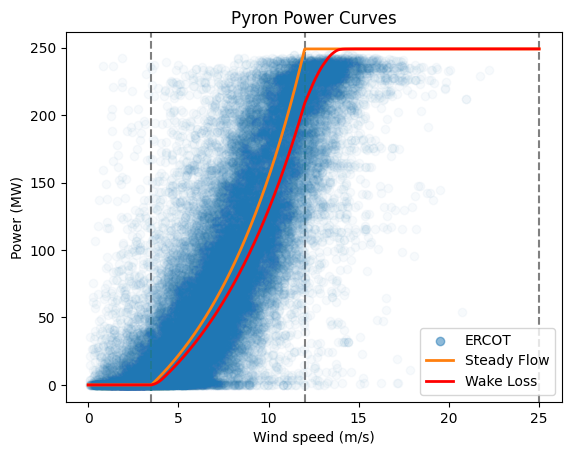

In [503]:
plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.plot(x, y, label='Steady Flow', linewidth=2, color='tab:orange')
plt.plot(x, y_wakeloss, color='red', label='Wake Loss', linewidth=2)

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Pyron Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

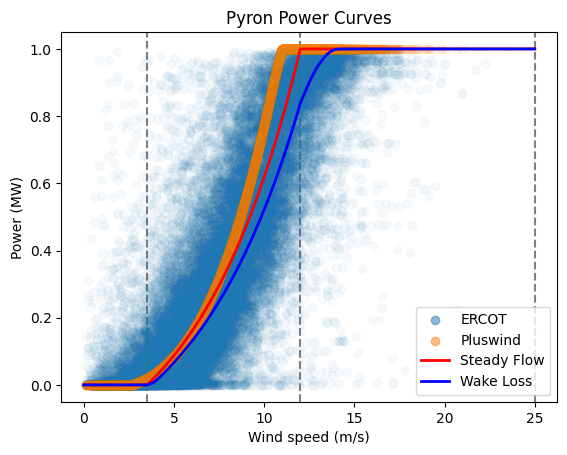

In [150]:
# normalized power curves
y_norm = [val / 249 for val in y]
y_wakeloss_norm = [val / 249 for val in y_wakeloss]

plt.scatter(df['speed'], df['npower'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], df['power_cf'], alpha=0.03, label='Pluswind')
plt.plot(x, y_norm, color='red', label='Steady Flow', linewidth=2)
plt.plot(x, y_wakeloss_norm, color='blue', label='Wake Loss', linewidth=2)

plt.axvline(3.5, linestyle='--', color='gray', zorder=0)
plt.axvline(12, linestyle='--', color='gray', zorder=0)
plt.axvline(25, linestyle='--', color='gray', zorder=0)

plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Pyron Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

## time series with wake loss

In [155]:
stead_power = full_power_curve(df['speed'], *params)
wake_power = power_wakeloss(df['speed'], turbines, params)

In [ ]:
stead_power_norm = np.array(stead_power) / 249
wake_power_norm = np.array(wake_power) / 249

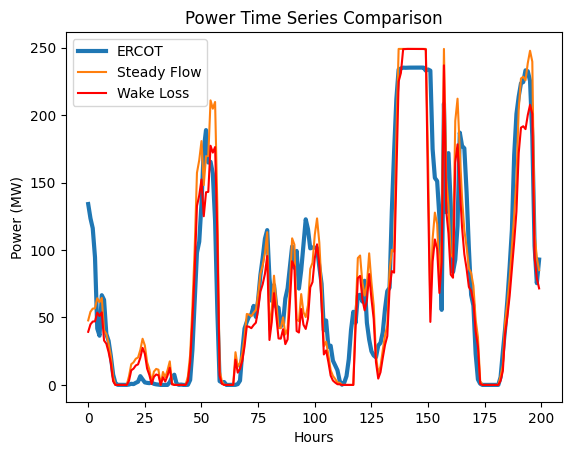

In [499]:
plt.plot(df['power'][0:200].reset_index(drop=True), label='ERCOT', linewidth=3)
plt.plot(stead_power[0:200], label='Steady Flow')
plt.plot(wake_power[0:200], label='Wake Loss', color='red')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Power Time Series Comparison')
plt.legend()

In [164]:
# compare ERCOT vs Steady Flow
print("MSE:", mean_squared_error(df['npower'], stead_power_norm))
print("RMSE:", root_mean_squared_error(df['npower'], stead_power_norm))
print("R2:", r2_score(df['npower'], stead_power_norm))

MSE: 0.037122683541293965
RMSE: 0.1926724773840155
R2: 0.6086496883475956


In [165]:
# compare ERCOT vs Wake Loss
print("MSE:", mean_squared_error(df['npower'], wake_power_norm))
print("RMSE:", root_mean_squared_error(df['npower'], wake_power_norm))
print("R2:", r2_score(df['npower'], wake_power_norm))

MSE: 0.036442010717730754
RMSE: 0.19089790653050848
R2: 0.615825395926453


# Simulating variability in wake loss

In [ ]:
# P = power_wakeloss(sp, turbines, params) + noise
# noise

In [ ]:
from scipy.interpolate import make_splrep

In [ ]:
df['wake_power'] = wake_power

In [284]:
# bin and fit std parameter to the historical power, as function of wind speed
def fit_std(speed, power, intervals, k=3, s=0):
    params = pd.DataFrame(columns=['avg_speed', 'std'])
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speed >= lower) & (speed < upper)]
        std = np.std(filtered_power)
        print(std)
        params.loc[len(params)] = [avg_speed, std]
        # print(list(norm.fit(filtered_power, floc=0)))
        # params.loc[len(params)] = [avg_speed] + list(norm.fit(filtered_power, floc=10))

    std_spline = make_splrep(np.array(params['avg_speed']), np.array(params['std']), k=k, s=s)

    return std_spline

In [282]:
intervals = np.append(np.arange(0, 19, 1), 24)

In [274]:
df['wake_power']

0        39.351492
1        44.911648
2        46.951095
3        47.143199
4        53.601241
           ...    
34851     0.000000
34852     0.000000
34853     0.609756
34854    12.964005
34855    29.125025
Name: wake_power, Length: 34856, dtype: float64

In [289]:
std_spline = fit_std(df['speed'], df['power'], intervals)

22.216607476811753
28.24795803828817
25.274188960177963
28.292700353917958
35.157385476755586
38.114301697431436
42.539282328184136
46.7773559518138
50.824853205627804
51.75048595203563
50.54955934338204
48.11272287346695
43.79792030133576
43.106640615271104
45.81788899732495
49.7658056737515
46.22050595111153
65.17953315789845
52.97388786320511


22.216607476811753
28.24795803828817
25.274188960177963
28.292700353917958
35.157385476755586
38.114301697431436
42.539282328184136
46.7773559518138
50.824853205627804
51.75048595203563
50.54955934338204
48.11272287346695
43.79792030133576
43.106640615271104
45.81788899732495
49.7658056737515
46.22050595111153
65.17953315789845
52.97388786320511


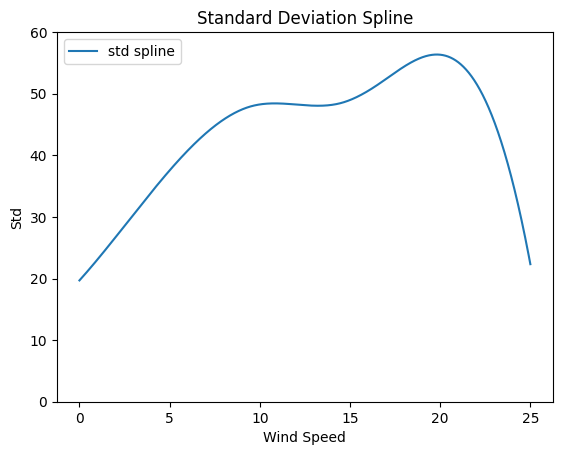

In [511]:
std_spline = fit_std(df['speed'], df['power'], intervals, k=3, s=300)

x = np.linspace(0, 25, 10000)
y = std_spline(x)
plt.plot(x, y, label='std spline')
# plt.scatter(intervals[:-1], [std_spline(i) for i in intervals[:-1]], marker='o', label='std_spline points')
plt.title('Standard Deviation Spline')
plt.xlabel('Wind Speed')
plt.ylabel('Std')
plt.ylim(0, 60)
plt.legend()

In [384]:
# normal noise

def apply_noise(speed, power, std_spline):
    noise = np.random.normal(0, std_spline(speed), size=1)
    init_power = power + noise
    if init_power < 0 or init_power > 249:
        noise = -noise / 3
    return (power + noise)[0]

power_noise = df.apply(lambda row: apply_noise(row['speed'], row['wake_power'], std_spline), axis=1)
# power_noise = np.clip(power_noise, 0, 249)  # ensure power is within bounds
# power_noise = df['wake_power'] + noise

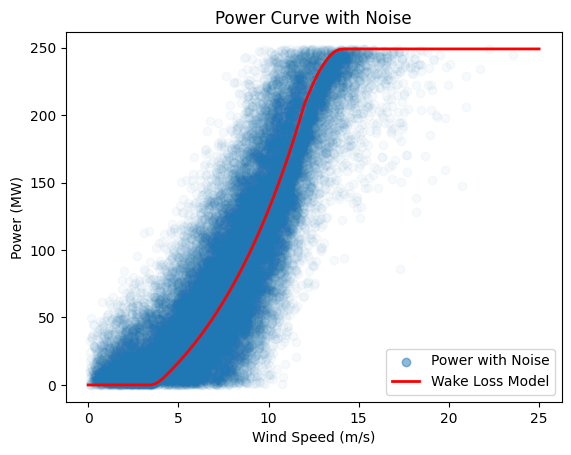

In [514]:
# plt.scatter(df['speed'], df['power'], alpha=0.03, label='ERCOT')
plt.scatter(df['speed'], power_noise, alpha=0.03, label='Power with Noise')

x = np.linspace(0, 25, 1000)
plt.plot(x, y_wakeloss, color='red', label='Wake Loss Model', linewidth=2)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Power Curve with Noise')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

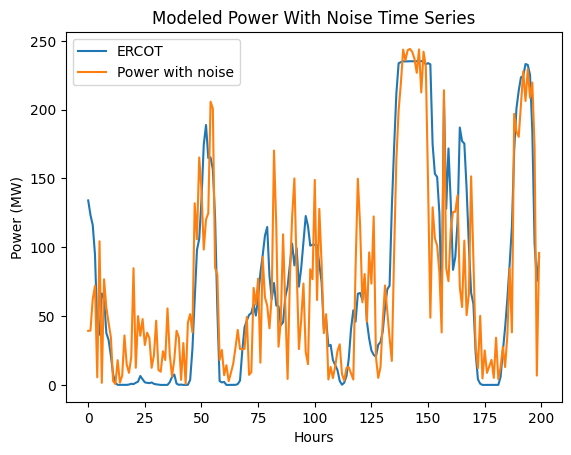

In [524]:
plt.plot(df['power'][:200], label='ERCOT')
plt.plot(power_noise[:200], label='Power with noise')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Modeled Power With Noise Time Series')
plt.legend()

# Temporal sorting

In [444]:
df1 = df[:8760]

In [445]:
df1

,datetime,speed,power_cf,power,npower,nspeed,npower_clipped,wake_power,beta_samples,power_noise,npower_noise
0,2018-01-01 01:00:00,6.384246,0.191033,134.039,0.548825,0.268745,0.548825,39.351492,0.007085,39.280672,0.157743
1,2018-01-01 02:00:00,6.679563,0.220842,123.450,0.505468,0.281334,0.505468,44.911648,0.094090,39.438021,0.158375
2,2018-01-01 03:00:00,6.784414,0.232067,116.143,0.475550,0.285803,0.475550,46.951095,36.672872,62.364762,0.250456
3,2018-01-01 04:00:00,6.794198,0.233133,94.625,0.387444,0.286221,0.387444,47.143199,154.990244,72.039506,0.289314
4,2018-01-01 05:00:00,7.114358,0.269688,41.765,0.171008,0.299868,0.171008,53.601241,0.319158,5.517149,0.022137
...,...,...,...,...,...,...,...,...,...,...,...
8755,2019-01-07 19:00:00,8.718971,0.508579,127.428,0.521756,0.368270,0.521756,91.579181,60.921671,128.073618,0.514366
8756,2019-01-07 20:00:00,8.547322,0.478290,175.983,0.720566,0.360953,0.720566,87.024709,191.490975,29.684201,0.119200
8757,2019-01-07 21:00:00,8.944390,0.550159,189.099,0.774269,0.377879,0.774269,97.758172,237.837411,175.521804,0.704934
8758,2019-01-07 22:00:00,9.245805,0.609072,188.020,0.769851,0.390728,0.769851,106.385265,245.383420,134.974808,0.542083


In [565]:
# daily cycles average
(df1[:24]['power_noise'].max() - df1[:24]['power_noise'].min()) / 2

51.904183434694794

In [566]:
(df1['power_noise'].max() - df1['power_noise'].min()) / 2

124.48863065275643

In [567]:
t = np.arange(8760)
A = 124
B = 52

seasonal = A * np.sin(2 * np.pi * t / 8760)
daily = B * np.sin(2 * np.pi * t / 24)
noise = np.random.normal(0, 3, size=8760)
weight = seasonal + daily + noise

sort_indices = np.argsort(df1['power_noise'])
sorted_power = df1['power_noise'].values[sort_indices]
sorted_speeeed = df1['speed'].values[sort_indices]
weight_order = np.argsort(weight)

sorted = np.empty_like(sorted_power)
sorted_speed = np.empty_like(sorted_power)

sorted[weight_order] = sorted_power
sorted_speed[weight_order] = sorted_speeeed

781094.34823612

In [557]:
ercot_power = df1['power']
t = np.arange(len(ercot_power))
seasonal = np.sin(2 * np.pi * t / 8760)
diurnal = np.sin(2 * np.pi * t / 24)

A = 0.5 * (np.max(ercot_power) - np.min(ercot_power)) * np.corrcoef(ercot_power, seasonal)[0, 1]
B = 0.5 * (np.max(ercot_power) - np.min(ercot_power)) * np.corrcoef(ercot_power, diurnal)[0, 1]

6.920267803592059

In [560]:
seasonal = A * np.sin(2 * np.pi * t / 8760)
daily = B * np.sin(2 * np.pi * t / 24)
noise = np.random.normal(0, 1, size=8760)
weight = A * seasonal + B * daily + noise

# sorted_power = np.sort(df1['power_noise'])
# weight_order = np.argsort(weight)
# sorted = np.empty_like(sorted_power)
# sorted[weight_order] = sorted_power

sort_indices = np.argsort(df1['power_noise'])
sorted_power = df1['power_noise'].values[sort_indices]
sorted_speeeed = df1['speed'].values[sort_indices]
weight_order = np.argsort(weight)

sorted = np.empty_like(sorted_power)
sorted_speed = np.empty_like(sorted_power)

sorted[weight_order] = sorted_power
sorted_speed[weight_order] = sorted_speeeed

In [561]:
sorted.sum()

781094.34823612

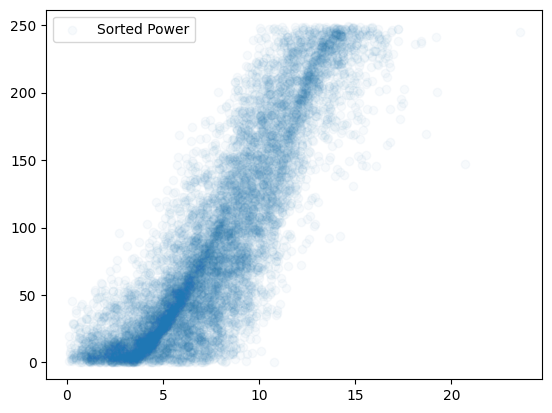

In [568]:
plt.scatter(sorted_speed, sorted, alpha=0.03, label='Sorted Power')
# plt.scatter(df1['speed'], df1['power_noise'], alpha=0.03, label='orig Power')
plt.legend()

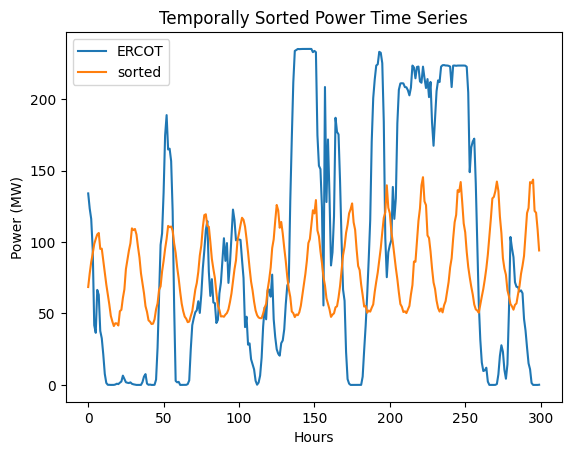

In [572]:
plt.plot(df1['power'][:300], label='ERCOT')
plt.plot(sorted[:300], label='sorted')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Temporally Sorted Power Time Series')
plt.legend()

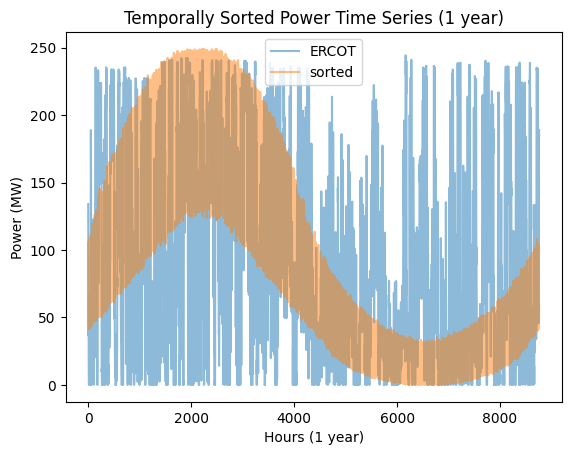

In [582]:
plt.plot(df1['power'], label='ERCOT', alpha=0.5)
plt.plot(sorted, label='sorted', alpha=0.5)
plt.xlabel('Hours (1 year)')
plt.ylabel('Power (MW)')
plt.title('Temporally Sorted Power Time Series (1 year)')
plt.legend()

## Autoregressive smoothing

$ P_t = \alpha \cdot P_{t-1} + (1 - \alpha) \cdot \epsilon_t $

$ P_t = \alpha \cdot P_{t-1} + (1 - \alpha) \cdot P_t $

In [515]:
def ar_smooth(power, alpha=0.9):
    smoothed = np.zeros_like(power)
    smoothed[0] = power[0]  # Initialize with the first value
    for t in range(1, len(power)):
        smoothed[t] = alpha * smoothed[t-1] + (1 - alpha) * power[t]
    return smoothed

Text(0.5, 1.0, 'Temporally Sorted Power Curve (after smoothing)')

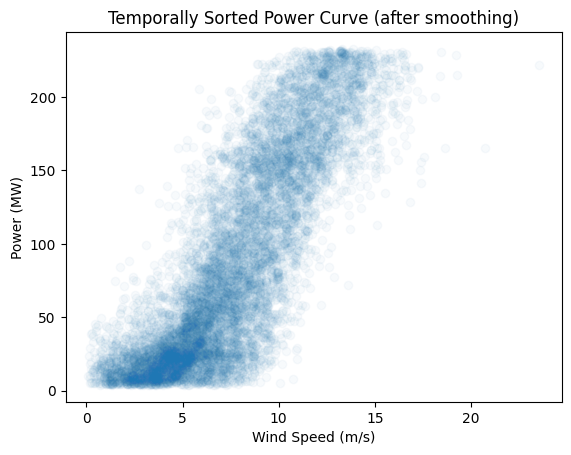

In [576]:
temp_smoothed = ar_smooth(sorted, alpha=0.8)
plt.scatter(sorted_speed, temp_smoothed, alpha=0.03, label='Smoothed Power')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Temporally Sorted Power Curve (after smoothing)')

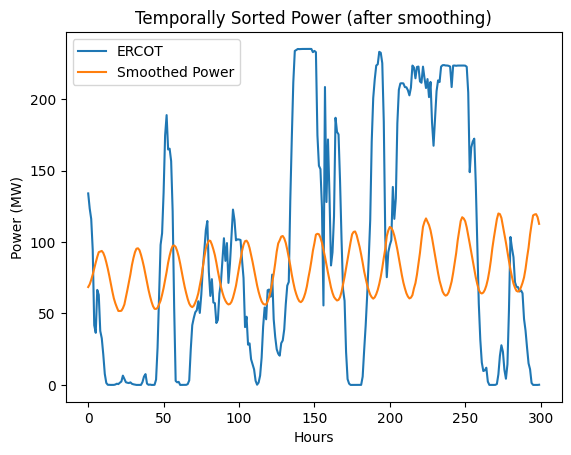

In [578]:
plt.plot(df1['power'][:300], label='ERCOT')
plt.plot(temp_smoothed[:300], label='Smoothed Power')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title('Temporally Sorted Power (after smoothing)')
plt.legend()

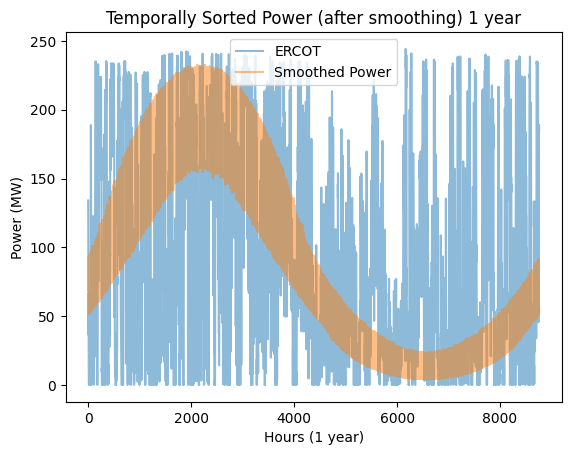

In [581]:
plt.plot(df1['power'], label='ERCOT', alpha=0.5)
plt.plot(temp_smoothed, label='Smoothed Power', alpha=0.5)
plt.xlabel('Hours (1 year)')
plt.ylabel('Power (MW)')
plt.title('Temporally Sorted Power (after smoothing) 1 year')
plt.legend()

In [554]:
power_noise_smoothed = ar_smooth(power_noise, alpha=0.7)

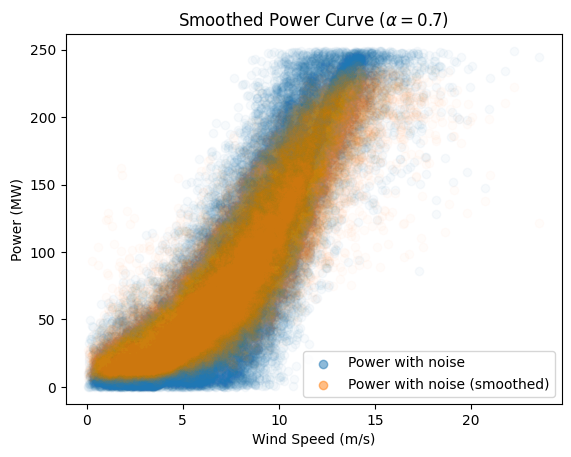

In [555]:
plt.scatter(df['speed'], power_noise, alpha=0.03, label='Power with noise')
plt.scatter(df['speed'], power_noise_smoothed, alpha=0.02, label='Power with noise (smoothed)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title(r'Smoothed Power Curve $(\alpha=0.7)$')

leg = plt.legend()
for lh in leg.legend_handles:
    lh.set_alpha(0.5)

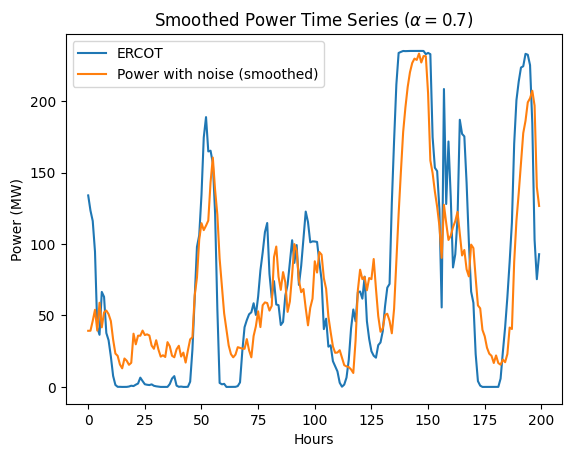

In [556]:
plt.plot(df['power'][:200], label='ERCOT')
plt.plot(power_noise_smoothed[:200], label='Power with noise (smoothed)')
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.title(r'Smoothed Power Time Series $(\alpha=0.7)$')
plt.legend()

In [542]:
npower_noise_smoothed = (power_noise_smoothed - power_noise_smoothed.min()) / (power_noise_smoothed.max() - power_noise_smoothed.min())

In [550]:
mse = mean_squared_error(df['npower'], npower_noise_smoothed)
print("MSE:", mse)

rmse = root_mean_squared_error(df['npower'], npower_noise_smoothed)
print("RMSE:", rmse)

MSE: 0.039774057286324584
RMSE: 0.19943434329704748
